📂 Collecting one sample per class...
  ✅ Algal Leaf Spot: tea_algal_leaf_spot_00294.jpg
  ✅ Brown Blight: brown_blight_00352.jpg
  ✅ Gray Blight: gray_blight_00680.jpg
  ✅ Helopeltis: helopeltis_00079.jpg
  ✅ Red Spider: red_spider_00251.jpg
  ✅ Green Mirid Bug: green_mirid_bug_01164.jpg
  ✅ Healthy: healthy_00632.jpg
✅ Saved to: ./sample_images_row.png


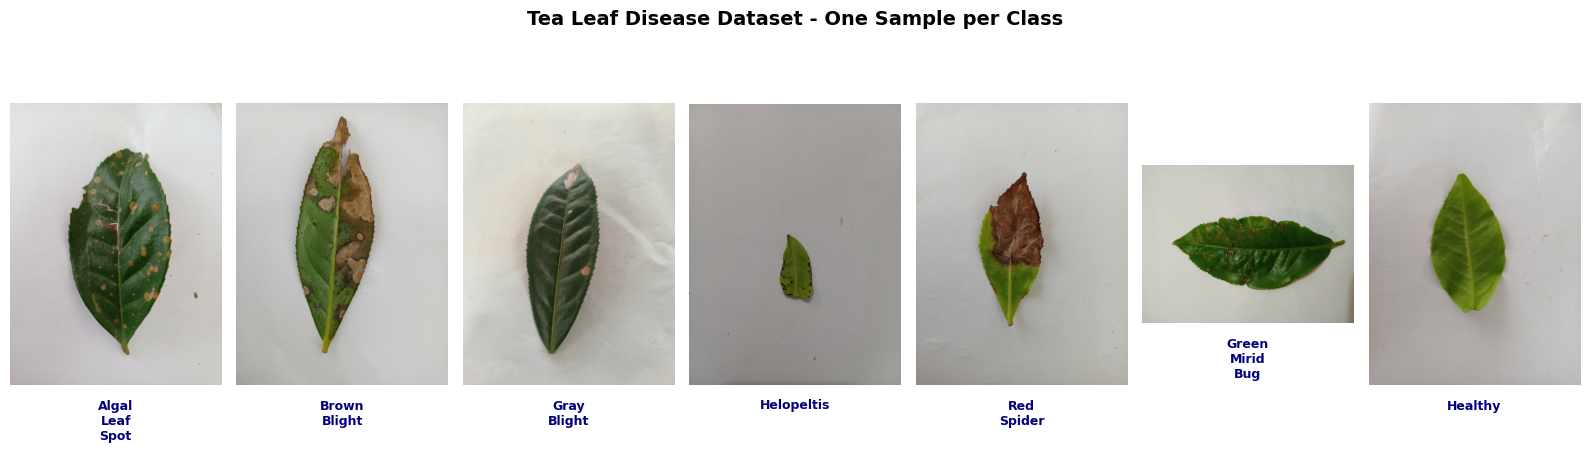


✅ Done! Check 'sample_images_row.png'


In [2]:
"""
Sample Images - One from Each Class
Single row visualization
"""

import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# ============================================================
# CONFIGURATION - UPDATE THIS PATH
# ============================================================
DATASET_ROOT = "/mnt/f415dcc8-27a5-4e66-8493-25f1d939974c/An Indivisual Research/teaLeafBD/newdataset/teaLeafBD"

# Class mapping (folder name -> class label)
CLASS_MAP = {
    "1. Tea algal leaf spot": "Algal Leaf Spot",
    "2. Brown Blight": "Brown Blight",
    "3. Gray Blight": "Gray Blight",
    "4. Helopeltis": "Helopeltis",
    "5. Red spider": "Red Spider",
    "6. Green mirid bug": "Green Mirid Bug",
    "7. Healthy leaf": "Healthy",
}

# ============================================================
# MAIN FUNCTION
# ============================================================

def get_one_sample_per_class(root, class_map):
    """
    Get one sample image from each class.
    
    Args:
        root: Path to dataset root
        class_map: Dictionary mapping folder names to class labels
    
    Returns:
        dict: {class_label: image_path}
    """
    root = Path(root)
    samples = {}
    
    print("📂 Collecting one sample per class...")
    
    for folder_name, class_label in class_map.items():
        class_dir = root / folder_name
        
        if not class_dir.exists():
            print(f"  ⚠️ Folder not found: {folder_name}")
            continue
        
        # Get first image from folder
        image_files = []
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            image_files.extend(class_dir.glob(f"*{ext}"))
        
        if image_files:
            samples[class_label] = image_files[0]  # Take first image
            print(f"  ✅ {class_label}: {image_files[0].name}")
        else:
            print(f"  ⚠️ No images found in: {folder_name}")
    
    return samples

def display_single_row(samples, class_labels, figsize=(16, 4), save_path=None):
    """
    Display one sample per class in a single row.
    
    Args:
        samples: Dictionary of {class_label: image_path}
        class_labels: List of class names in order
        figsize: Figure size (width, height)
        save_path: Path to save the figure
    """
    n_classes = len(class_labels)
    
    fig, axes = plt.subplots(1, n_classes, figsize=figsize)
    
    for i, class_label in enumerate(class_labels):
        ax = axes[i]
        
        # Get image path for this class
        img_path = samples.get(class_label)
        
        if img_path and img_path.exists():
            try:
                img = Image.open(img_path).convert('RGB')
                ax.imshow(img)
                
                # Add class name below image
                # Shorten long names
                short_name = class_label.replace(' ', '\n')
                ax.set_xlabel(short_name, fontsize=9, fontweight='bold', 
                            color='navy', labelpad=10)
                
            except Exception as e:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
        
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        # Remove spines for cleaner look
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    # Add title
    plt.suptitle('Tea Leaf Disease Dataset - One Sample per Class', 
                fontsize=14, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved to: {save_path}")
    
    plt.show()
    return fig

# ============================================================
# EXECUTION
# ============================================================

if __name__ == "__main__":
    # Set random seed for reproducibility
    random.seed(42)
    
    # Class labels in order
    CLASS_LABELS = list(CLASS_MAP.values())
    
    # Get one sample per class
    samples = get_one_sample_per_class(DATASET_ROOT, CLASS_MAP)
    
    # Display in single row
    display_single_row(
        samples, 
        CLASS_LABELS,
        figsize=(16, 4),
        save_path="./sample_images_row.png"
    )
    
    print("\n✅ Done! Check 'sample_images_row.png'")